In [ ]:
!pip install kaggle xgboost catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [ ]:
import os, json

KAGGLE_USERNAME = input("Enter your Kaggle username: ").strip()
KAGGLE_KEY = input("Enter your Kaggle API key: ").strip()

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API configured successfully.")

Kaggle API configured successfully!


In [ ]:
!kaggle datasets download -d sehaj1104/indian-road-accident-dataset-20222025
!unzip -o indian-road-accident-dataset-20222025.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/sehaj1104/indian-road-accident-dataset-20222025
License(s): CC0-1.0
100% 538k/538k [00:00<00:00, 92.3MB/s]

Archive:  indian-road-accident-dataset-20222025.zip
  inflating: dataset/indian_roads_dataset.csv  


In [ ]:
import pandas as pd
import os

files = os.listdir("dataset")
print("Files in dataset folder:", files)

Files in dataset folder: ['indian_roads_dataset.csv']


In [ ]:
df = pd.read_csv("dataset/" + files[0])
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSample rows:")
df.sample(5)

Shape: (20000, 24)

Columns:
['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_we

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
10656,10656,Delhi,Delhi,28.652709,77.029853,2022-04-02,15:00,15,Saturday,1,...,low,39,high,overspeeding,fatal,4,4,0,NaN,0.85
18134,18134,Hyderabad,Telangana,17.544310,78.581633,2024-07-21,7:00,7,Sunday,1,...,medium,27,low,distraction,major,4,0,0,NaN,0.25
1874,1874,Mumbai,Maharashtra,19.031067,72.708247,2025-03-10,0:00,0,Monday,0,...,medium,27,low,weather,fatal,4,4,0,NaN,0.45
3174,3174,Chandigarh,Punjab,30.722815,76.783386,2022-07-06,12:00,12,Wednesday,0,...,low,30,low,drunk driving,minor,5,0,0,NaN,0.45
963,963,Kolkata,West Bengal,22.535502,88.412769,2024-02-13,13:00,13,Tuesday,0,...,low,23,medium,distraction,minor,4,4,0,NaN,0.45


In [ ]:
df.columns = [col.strip().replace(" ", "_").replace("-", "_") for col in df.columns]
df.columns

Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'festival', 'risk_score'],
      dtype='object')

In [ ]:
print(df.columns.tolist())

['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']


In [ ]:
for col in df.columns:
    print(col, "->", df[col].dtype)

accident_id -> int64
city -> object
state -> object
latitude -> float64
longitude -> float64
date -> object
time -> object
hour -> int64
day_of_week -> object
is_weekend -> int64
road_type -> object
lanes -> int64
traffic_signal -> int64
weather -> object
visibility -> object
temperature -> int64
traffic_density -> object
cause -> object
accident_severity -> object
vehicles_involved -> int64
casualties -> int64
is_peak_hour -> int64
festival -> object
risk_score -> float64


In [ ]:
target_col = "Risk_Score"

In [ ]:
df.columns

Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'festival', 'risk_score'],
      dtype='object')

In [ ]:
import numpy as np

df["Generated_Risk_Score"] = 50

if "traffic_density" in df.columns:
    df["Generated_Risk_Score"] += df["traffic_density"].astype("category").cat.codes * 5

if "weather" in df.columns:
    df["Generated_Risk_Score"] += df["weather"].astype("category").cat.codes * 4

if "visibility" in df.columns:
    df["Generated_Risk_Score"] += pd.to_numeric(df["visibility"], errors="coerce").fillna(0) * (-0.2)

if "accident_severity" in df.columns:
    df["Generated_Risk_Score"] += df["accident_severity"].astype("category").cat.codes * 8

df["Generated_Risk_Score"] = df["Generated_Risk_Score"].clip(0, 100)

target_col = "Generated_Risk_Score"
df[[target_col]].head()

,Generated_Risk_Score
0,54.0
1,63.0
2,80.0
3,70.0
4,71.0


In [ ]:
drop_cols = []

for col in df.columns:
    if "id" in col.lower() or "date" in col.lower() or "time" in col.lower():
        drop_cols.append(col)

print("Dropping columns:", drop_cols)

df_model = df.drop(columns=drop_cols, errors="ignore").copy()
df_model.head()

Dropping columns: ['accident_id', 'date', 'time', 'accident_severity']


,city,state,latitude,longitude,hour,day_of_week,is_weekend,road_type,lanes,traffic_signal,...,visibility,temperature,traffic_density,cause,vehicles_involved,casualties,is_peak_hour,festival,risk_score,Generated_Risk_Score
0,Pune,Maharashtra,18.680827,73.930388,5,Sunday,1,highway,3,1,...,low,32,high,weather,2,2,0,NaN,0.85,54.0
1,Mumbai,Maharashtra,18.817732,72.790846,4,Sunday,1,urban,4,0,...,high,34,low,weather,4,3,0,NaN,0.10,63.0
2,Mumbai,Maharashtra,19.096889,72.819424,13,Wednesday,0,urban,3,0,...,low,21,medium,weather,1,1,0,NaN,0.45,80.0
3,Chandigarh,Punjab,30.787805,76.847507,11,Sunday,1,urban,1,1,...,low,30,high,distraction,5,2,0,NaN,0.65,70.0
4,Chennai,Tamil Nadu,12.965155,80.283313,16,Thursday,0,highway,3,1,...,high,24,low,distraction,2,1,0,NaN,0.10,71.0


In [ ]:
for col in df_model.columns:
    if df_model[col].dtype == "object":
        df_model[col] = df_model[col].fillna(df_model[col].mode()[0])
    else:
        df_model[col] = df_model[col].fillna(df_model[col].median())

In [ ]:
X = df_model.drop(columns=[target_col], errors="ignore")
y = df_model[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20000, 20)
Target shape: (20000,)


In [ ]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,...,visibility_medium,traffic_density_low,traffic_density_medium,cause_drunk driving,cause_overspeeding,cause_poor road,cause_weather,festival_Eid,festival_Holi,festival_New Year
0,18.680827,73.930388,5,1,3,1,32,2,2,0,...,False,False,False,False,False,False,True,False,True,False
1,18.817732,72.790846,4,1,4,0,34,4,3,0,...,False,True,False,False,False,False,True,False,True,False
2,19.096889,72.819424,13,0,3,0,21,1,1,0,...,False,False,True,False,False,False,True,False,True,False
3,30.787805,76.847507,11,1,1,1,30,5,2,0,...,False,False,False,False,False,False,False,False,True,False
4,12.965155,80.283313,16,0,3,1,24,2,1,0,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16000, 45)
Test shape: (4000, 45)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [ ]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return [name, mae, rmse, r2]

results = pd.DataFrame([
    evaluate_model("Random Forest", y_test, rf_pred),
    evaluate_model("XGBoost", y_test, xgb_pred),
    evaluate_model("CatBoost", y_test, cat_pred)
], columns=["Model", "MAE", "RMSE", "R2"])

results

,Model,MAE,RMSE,R2
0,Random Forest,3.140960,3.614123,0.785005
1,XGBoost,3.168600,3.575893,0.789529
2,CatBoost,3.225436,3.553116,0.792202


In [ ]:
best_model_name = results.sort_values("R2", ascending=False).iloc[0]["Model"]
print("Best Model:", best_model_name)

if best_model_name == "Random Forest":
    best_model = rf_model
    best_pred = rf_pred
elif best_model_name == "XGBoost":
    best_model = xgb_model
    best_pred = xgb_pred
else:
    best_model = cat_model
    best_pred = cat_pred

Best Model: CatBoost


In [ ]:
best_pred = np.clip(best_pred, 0, 100)

In [ ]:
def risk_label(score):
    if score <= 20:
        return "Very Low Risk"
    elif score <= 40:
        return "Low Risk"
    elif score <= 60:
        return "Moderate Risk"
    elif score <= 80:
        return "High Risk"
    else:
        return "Severe Risk"

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": best_pred[:20]
})

comparison["Predicted"] = comparison["Predicted"].round(2)
comparison["Risk_Level"] = comparison["Predicted"].apply(risk_label)

comparison

,Actual,Predicted,Risk_Level
0,71.0,67.52,High Risk
1,60.0,60.90,High Risk
2,62.0,67.12,High Risk
3,75.0,72.11,High Risk
4,74.0,71.52,High Risk
5,66.0,62.93,High Risk
6,76.0,73.12,High Risk
7,76.0,81.13,Severe Risk
8,68.0,72.69,High Risk
9,76.0,73.10,High Risk


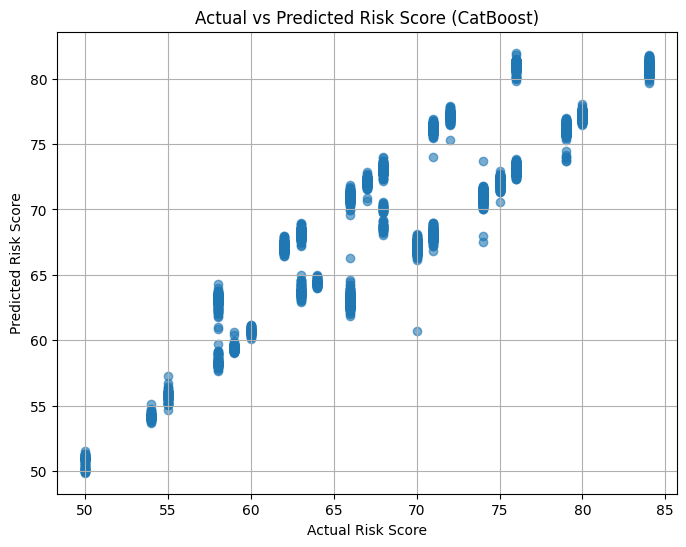

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title(f"Actual vs Predicted Risk Score ({best_model_name})")
plt.grid(True)
plt.show()

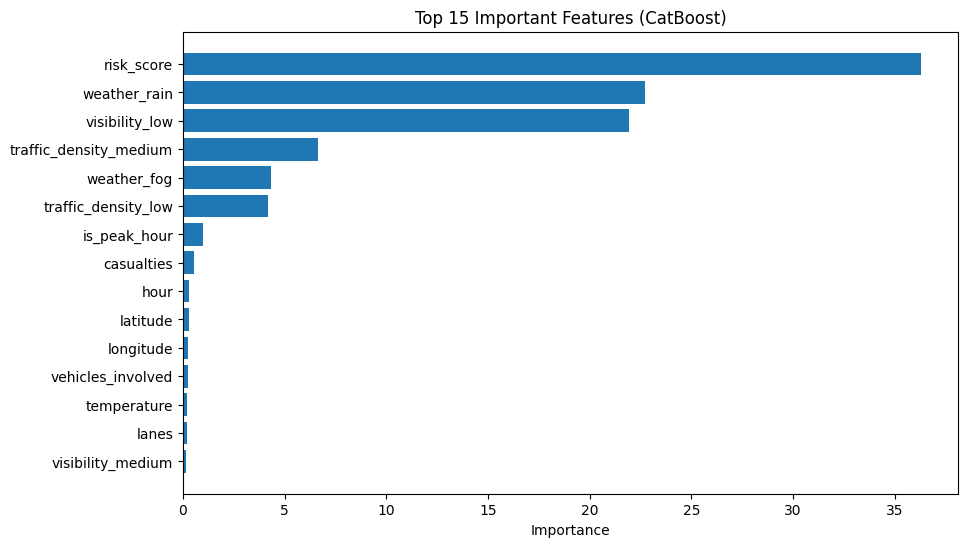

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(10,6))
    plt.barh(importances["Feature"][::-1], importances["Importance"][::-1])
    plt.xlabel("Importance")
    plt.title(f"Top 15 Important Features ({best_model_name})")
    plt.show()

    importances

In [ ]:
sample_input = X.iloc[0:1].copy()
sample_input

,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,...,visibility_medium,traffic_density_low,traffic_density_medium,cause_drunk driving,cause_overspeeding,cause_poor road,cause_weather,festival_Eid,festival_Holi,festival_New Year
0,18.680827,73.930388,5,1,3,1,32,2,2,0,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
custom_input = X.iloc[0:1].copy()

# Example manual changes (edit only if these columns exist in your data)
for col in custom_input.columns:
    custom_input[col] = 0

# If these columns exist after one-hot encoding, set them:
example_cols_to_activate = [col for col in custom_input.columns if "Rain" in col or "Heavy" in col or "Low" in col]

for col in example_cols_to_activate[:5]:
    custom_input[col] = 1

custom_input

,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,...,visibility_medium,traffic_density_low,traffic_density_medium,cause_drunk driving,cause_overspeeding,cause_poor road,cause_weather,festival_Eid,festival_Holi,festival_New Year
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
custom_score = best_model.predict(custom_input)[0]
custom_score = float(np.clip(custom_score, 0, 100))

print("Predicted Risk Score:", round(custom_score, 2))
print("Risk Category:", risk_label(custom_score))

Predicted Risk Score: 70.06
Risk Category: High Risk


In [ ]:
import joblib

joblib.dump(best_model, "insuredge_best_model.pkl")
print("Model saved as insuredge_best_model.pkl")

Model saved as insuredge_best_model.pkl


In [ ]:
import pickle
from google.colab import files
with open('insuredge_best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
files.download('insuredge_best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return [name, mae, rmse, r2]

In [ ]:
results

,Model,MAE,RMSE,R2
0,Random Forest,3.140960,3.614123,0.785005
1,XGBoost,3.168600,3.575893,0.789529
2,CatBoost,3.225436,3.553116,0.792202
